# House Price Prediction - Training and Testing Pipeline

This notebook demonstrates a complete machine learning workflow for predicting house prices using XGBoost. The pipeline includes data loading, feature engineering, model training, evaluation, and model persistence.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor

In [2]:
df = pd.read_csv('/home/sukesh/Desktop/RealtyAI/B-13-RealtyAI-Smart-Real-Estate-Insight-Platform/dataset/cleaned_data.csv')

## Load Dataset

Load the cleaned dataset containing house price information.

In [3]:
df["Sale_time"] = df["Year"] * 12 + df["Month"]

## Feature Engineering

Create a temporal feature that combines year and month into a single continuous variable to capture sale trends over time.

Formula: Sale_time = Year × 12 + Month

In [4]:
df

,Price,Old/New,Town/City,District,County,PPDCategory Type,Property Type_D,Property Type_F,Property Type_O,Property Type_S,Property Type_T,Duration_F,Duration_L,Duration_U,Year,Month,Price_scaled,Price_minmax,Sale_time
0,10.126671,1,OLDHAM,OLDHAM,GREATER MANCHESTER,0,0,0,0,0,1,1,0,0,1995,8,-1.401577,0.250575,23948
1,10.657283,1,GRAYS,THURROCK,THURROCK,0,0,0,0,1,0,1,0,0,1995,8,-0.493593,0.335777,23948
2,10.714440,1,HIGHBRIDGE,SEDGEMOOR,SOMERSET,0,0,0,0,0,1,1,0,0,1995,6,-0.395786,0.344955,23946
3,10.672461,1,BEDFORD,NORTH BEDFORDSHIRE,BEDFORDSHIRE,0,0,0,0,0,1,1,0,0,1995,11,-0.467621,0.338215,23951
4,9.846917,1,WAKEFIELD,LEEDS,WEST YORKSHIRE,0,0,0,0,1,0,1,0,0,1995,6,-1.880292,0.205654,23946
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,10.703267,1,STOWMARKET,MID SUFFOLK,SUFFOLK,0,0,0,0,1,0,1,0,0,1995,12,-0.414905,0.343161,23952
99996,10.778977,1,THORNTON-CLEVELEYS,WYRE,LANCASHIRE,0,0,0,0,1,0,1,0,0,1995,2,-0.285350,0.355318,23942
99997,11.350418,1,ST. ALBANS,ST ALBANS,HERTFORDSHIRE,0,0,0,0,1,0,1,0,0,1995,11,0.692501,0.447077,23951
99998,10.778977,1,LEEDS,LEEDS,WEST YORKSHIRE,0,0,0,0,1,0,1,0,0,1995,9,-0.285350,0.355318,23949


In [5]:
X = df.drop("Price", axis=1)
y = df["Price"]

## Data Preparation

Separate the features (X) from the target variable (Price).

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

## Train-Test Split

Divide the dataset into 80% training and 20% testing data to ensure model evaluation on unseen data.

In [7]:
train_temp = X_train.copy()
train_temp["Price"] = y_train
city_mean = train_temp.groupby("Town/City")["Price"].mean()
X_train["Town_encoded"] = X_train["Town/City"].map(city_mean)
X_test["Town_encoded"] = X_test["Town/City"].map(city_mean)
global_mean = y_train.mean()
X_test["Town_encoded"] = X_test["Town_encoded"].fillna(global_mean)

## Target Encoding for High-Cardinality Location Feature

The Town/City column contains 1122 unique values, making one-hot encoding inefficient. We use **target encoding** (mean encoding) to encode location based on average house prices per city.

### Process:
1. Calculate mean price for each city in training data
2. Map cities to their average prices
3. Fill unknown cities with global mean price

In [8]:
df

,Price,Old/New,Town/City,District,County,PPDCategory Type,Property Type_D,Property Type_F,Property Type_O,Property Type_S,Property Type_T,Duration_F,Duration_L,Duration_U,Year,Month,Price_scaled,Price_minmax,Sale_time
0,10.126671,1,OLDHAM,OLDHAM,GREATER MANCHESTER,0,0,0,0,0,1,1,0,0,1995,8,-1.401577,0.250575,23948
1,10.657283,1,GRAYS,THURROCK,THURROCK,0,0,0,0,1,0,1,0,0,1995,8,-0.493593,0.335777,23948
2,10.714440,1,HIGHBRIDGE,SEDGEMOOR,SOMERSET,0,0,0,0,0,1,1,0,0,1995,6,-0.395786,0.344955,23946
3,10.672461,1,BEDFORD,NORTH BEDFORDSHIRE,BEDFORDSHIRE,0,0,0,0,0,1,1,0,0,1995,11,-0.467621,0.338215,23951
4,9.846917,1,WAKEFIELD,LEEDS,WEST YORKSHIRE,0,0,0,0,1,0,1,0,0,1995,6,-1.880292,0.205654,23946
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
99995,10.703267,1,STOWMARKET,MID SUFFOLK,SUFFOLK,0,0,0,0,1,0,1,0,0,1995,12,-0.414905,0.343161,23952
99996,10.778977,1,THORNTON-CLEVELEYS,WYRE,LANCASHIRE,0,0,0,0,1,0,1,0,0,1995,2,-0.285350,0.355318,23942
99997,11.350418,1,ST. ALBANS,ST ALBANS,HERTFORDSHIRE,0,0,0,0,1,0,1,0,0,1995,11,0.692501,0.447077,23951
99998,10.778977,1,LEEDS,LEEDS,WEST YORKSHIRE,0,0,0,0,1,0,1,0,0,1995,9,-0.285350,0.355318,23949


In [9]:
X_train.head()

,Old/New,Town/City,District,County,PPDCategory Type,Property Type_D,Property Type_F,Property Type_O,Property Type_S,Property Type_T,Duration_F,Duration_L,Duration_U,Year,Month,Price_scaled,Price_minmax,Sale_time,Town_encoded
75220,1,WORCESTER,MALVERN HILLS,WORCESTERSHIRE,0,1,0,0,0,0,1,0,0,1995,3,1.094354,0.484786,23943,10.992269
48955,1,DOVER,DOVER,KENT,0,0,0,0,0,1,1,0,0,1995,1,-1.189420,0.270483,23941,10.741893
44966,0,OKEHAMPTON,WEST DEVON,DEVON,0,0,0,0,1,0,1,0,0,1995,9,-0.685103,0.317807,23949,10.866644
13568,1,LEICESTER,BLABY,LEICESTERSHIRE,0,0,0,0,0,1,1,0,0,1995,2,-0.515882,0.333686,23942,10.778667
92727,1,LIVERPOOL,SEFTON,MERSEYSIDE,0,1,0,0,0,0,1,0,0,1995,10,0.478324,0.426979,23950,10.645854


In [10]:
X_train = X_train.drop(columns=["Town/City", "District", "County"])
X_test = X_test.drop(columns=["Town/City", "District", "County"])
X_train = X_train.drop(columns=["Price_scaled","Price_minmax"], errors="ignore")
X_test = X_test.drop(columns=["Price_scaled","Price_minmax"], errors="ignore")

## Drop Categorical Columns

Remove the original categorical columns (Town/City, District, County) and scaled price columns that are no longer needed after encoding.

In [11]:
model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    random_state=42
)

model.fit(X_train, y_train)

,"objective objective: typing.Union[str, xgboost.sklearn._SklObjWProto, typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]], NoneType]Specify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'reg:squarederror'
,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes

## Model Training

Train an **XGBoost Regressor** with optimized hyperparameters.

### Why XGBoost?
- Performs well on structured/tabular data
- Handles non-linear relationships effectively
- Provides strong predictive performance

In [12]:
y_pred = model.predict(X_test)

## Model Prediction

Generate predictions on the test set using the trained model.

In [13]:
print("MSE:", mean_squared_error(y_test, y_pred))
print("R2:", r2_score(y_test, y_pred))

MSE: 0.14912965830869607
R2: 0.5620591296679281


## Model Evaluation

Evaluate model performance using two key metrics:

### Metrics:
- **Mean Squared Error (MSE)**: Average squared difference between predicted and actual prices
- **R² Score**: Proportion of variance in prices explained by the model

In [14]:
results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": y_pred
})

results.head()

,Actual Price,Predicted Price
75721,12.128117,11.231022
80184,11.112463,10.752698
19864,10.942014,10.541510
76699,11.277216,10.569616
92991,10.752591,10.715146


In [15]:
results.head(20)

,Actual Price,Predicted Price
75721,12.128117,11.231022
80184,11.112463,10.752698
19864,10.942014,10.541510
76699,11.277216,10.569616
92991,10.752591,10.715146
76434,10.373522,10.251734
84004,10.545368,10.808784
80917,10.126671,10.611532
60767,10.703267,10.914987
50074,10.976799,11.439968


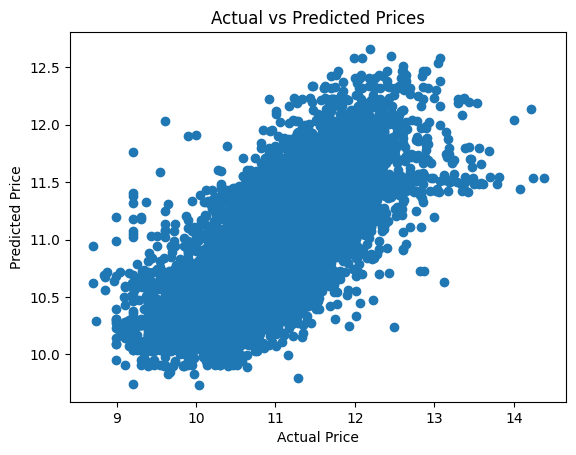

In [16]:
import matplotlib.pyplot as plt

plt.scatter(y_test, y_pred)
plt.xlabel("Actual Price")
plt.ylabel("Predicted Price")
plt.title("Actual vs Predicted Prices")
plt.show()

## Visualization

Visualize the relationship between actual and predicted prices to assess model accuracy visually.

In [17]:
new_house = pd.DataFrame({
    'Old/New':[1],
    'PPDCategory Type':[0],
    'Property Type_D':[0],
    'Property Type_F':[0],
    'Property Type_O':[0],
    'Property Type_S':[1],
    'Property Type_T':[0],
    'Duration_F':[1],
    'Duration_L':[0],
    'Duration_U':[0],
    'Year':[1995],
    'Month':[8],
    'Sale_time':[23948],
    'Town_encoded':[10.55]
})

model.predict(new_house)

array([10.664006], dtype=float32)

## Test with New Example

Test the trained model with a sample house to verify predictions work correctly.

In [18]:
import pickle

with open("house_price_model.pkl", "wb") as file:
    pickle.dump(model, file)

## Model Persistence - Save Model

Save the trained model to disk using pickle for future use and deployment without retraining.

In [19]:
with open("house_price_model.pkl", "rb") as file:
    loaded_model = pickle.load(file)

## Model Persistence - Load Model

Load the previously saved model from disk using pickle.

In [20]:
predictions = loaded_model.predict(X_test)

print(predictions)

[11.231022 10.752698 10.54151  ... 10.247377 11.04783  11.260015]


## Make Predictions with Loaded Model

Use the loaded model to make predictions on the test set, verifying that the saved model works correctly.